Khởi tạo Spark và đọc config

In [1]:
import sys
import os
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from pyspark.sql import functions as F
from pyspark.sql.window import Window

from src.config.spark_session import get_spark
from src.config.hdfs_config import SUPERSTORE_DATASET
from src.config.schema import SUPERSTORE_SCHEMA

spark = get_spark()
spark.sparkContext.setLogLevel("WARN")

print("Spark app name:", spark.sparkContext.appName)
print("Dataset path:", SUPERSTORE_DATASET)

Spark app name: Nhom10_BigData
Dataset path: hdfs://master:9000/bigdata/superstore/input/G10_dataset.csv


Đọc dữ liệu từ HDFS

In [2]:
df = (
    spark.read
    .option("header", "true")
    .option("dateFormat", "yyyy-MM-dd")
    .option("multiLine", "true")
    .option("quote", '"')
    .option("escape", '"')
    .option("mode", "PERMISSIVE")
    .schema(SUPERSTORE_SCHEMA)
    .csv(SUPERSTORE_DATASET)
)

df.printSchema()
df.show(5, truncate=False)

root
 |-- Category: string (nullable = true)
 |-- City: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- Customer_Name: string (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Market: string (nullable = true)
 |-- Order_Date: date (nullable = true)
 |-- Order_ID: string (nullable = true)
 |-- Order_Priority: string (nullable = true)
 |-- Product_ID: string (nullable = true)
 |-- Product_Name: string (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Sales: double (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Ship_Date: date (nullable = true)
 |-- Ship_Mode: string (nullable = true)
 |-- Shipping_Cost: double (nullable = true)
 |-- State: string (nullable = true)
 |-- Sub_Category: string (nullable = true)
 |-- Year: integer (nullable = true)
 |-- weeknum: integer (nullable = true)

+---------------+--------

Kiểm tra quy mô dữ liệu mới

In [3]:
basic_info = df.agg(
    F.count("*").alias("total_rows"),
    F.countDistinct("Order_ID").alias("total_orders"),
    F.countDistinct("Customer_ID").alias("total_customers"),
    F.min("Order_Date").alias("min_order_date"),
    F.max("Order_Date").alias("max_order_date")
)

basic_info.show(truncate=False)

print("Số cột:", len(df.columns))
print("Danh sách cột:")
print(df.columns)

+----------+------------+---------------+--------------+--------------+
|total_rows|total_orders|total_customers|min_order_date|max_order_date|
+----------+------------+---------------+--------------+--------------+
|500000    |236373      |33313          |2011-01-01    |2014-12-31    |
+----------+------------+---------------+--------------+--------------+

Số cột: 24
Danh sách cột:
['Category', 'City', 'Country', 'Customer_ID', 'Customer_Name', 'Discount', 'Market', 'Order_Date', 'Order_ID', 'Order_Priority', 'Product_ID', 'Product_Name', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship_Date', 'Ship_Mode', 'Shipping_Cost', 'State', 'Sub_Category', 'Year', 'weeknum']


Kiểm tra số lượng giá trị của các cột phân loại

In [4]:
categorical_cardinality = df.agg(
    F.countDistinct("Market").alias("n_market"),
    F.countDistinct("Region").alias("n_region"),
    F.countDistinct("Country").alias("n_country"),
    F.countDistinct("State").alias("n_state"),
    F.countDistinct("City").alias("n_city"),
    F.countDistinct("Segment").alias("n_segment"),
    F.countDistinct("Ship_Mode").alias("n_ship_mode"),
    F.countDistinct("Order_Priority").alias("n_order_priority"),
    F.countDistinct("Category").alias("n_category"),
    F.countDistinct("Sub_Category").alias("n_sub_category")
)

categorical_cardinality.show(truncate=False)

+--------+--------+---------+-------+------+---------+-----------+----------------+----------+--------------+
|n_market|n_region|n_country|n_state|n_city|n_segment|n_ship_mode|n_order_priority|n_category|n_sub_category|
+--------+--------+---------+-------+------+---------+-----------+----------------+----------+--------------+
|7       |13      |147      |1094   |3636  |3        |4          |4               |3         |17            |
+--------+--------+---------+-------+------+---------+-----------+----------------+----------+--------------+



Kiểm tra missing/null ở các cột quan trọng

In [5]:
important_cols = [
    "Customer_ID", "Customer_Name", "Order_ID", "Order_Date",
    "Product_ID", "Category", "Sub_Category",
    "Sales", "Profit", "Quantity", "Discount", "Shipping_Cost",
    "Market", "Region", "Country", "Segment",
    "Ship_Date", "Ship_Mode", "Order_Priority"
]

null_check_exprs = [
    F.sum(
        F.when(
            F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in important_cols
]

null_check = df.agg(*null_check_exprs)
null_check.show(truncate=False)

+-----------+-------------+--------+----------+----------+--------+------------+-----+------+--------+--------+-------------+------+------+-------+-------+---------+---------+--------------+
|Customer_ID|Customer_Name|Order_ID|Order_Date|Product_ID|Category|Sub_Category|Sales|Profit|Quantity|Discount|Shipping_Cost|Market|Region|Country|Segment|Ship_Date|Ship_Mode|Order_Priority|
+-----------+-------------+--------+----------+----------+--------+------------+-----+------+--------+--------+-------------+------+------+-------+-------+---------+---------+--------------+
|0          |0            |0       |0         |0         |0       |0           |0    |0     |0       |0       |0            |0     |0     |0      |0      |0        |0        |0             |
+-----------+-------------+--------+----------+----------+--------+------------+-----+------+--------+--------+-------------+------+------+-------+-------+---------+---------+--------------+



In [6]:
order_id_check = (
    df.groupBy("Order_ID")
    .agg(
        F.count("*").alias("line_count"),
        F.countDistinct("Customer_ID").alias("n_customers"),
        F.countDistinct("Customer_Name").alias("n_customer_names"),
        F.countDistinct("Order_Date").alias("n_order_dates")
    )
    .filter(
        (F.col("n_customers") > 1) |
        (F.col("n_customer_names") > 1) |
        (F.col("n_order_dates") > 1)
    )
)

print("Số Order_ID không duy nhất theo Customer/Date:", order_id_check.count())

order_id_check.orderBy(
    F.desc("n_customers"),
    F.desc("n_order_dates"),
    F.desc("line_count")
).show(20, truncate=False)

Số Order_ID không duy nhất theo Customer/Date: 660
+---------------+----------+-----------+----------------+-------------+
|Order_ID       |line_count|n_customers|n_customer_names|n_order_dates|
+---------------+----------+-----------+----------------+-------------+
|IT-2014-1036058|8         |4          |4               |4            |
|ES-2014-4717877|7         |4          |4               |4            |
|ES-2014-3566095|6         |4          |4               |4            |
|ES-2013-4477863|4         |4          |4               |4            |
|ES-2012-5776825|12        |3          |3               |3            |
|ES-2013-2700361|11        |3          |3               |3            |
|ES-2011-2075610|10        |3          |3               |3            |
|ES-2013-3575875|10        |3          |3               |3            |
|IT-2014-4652290|10        |3          |3               |3            |
|ES-2012-4435180|9         |3          |3               |3            |
|ES-2014-5631

Gom từ product-level về order-level

In [7]:
df_keyed = df.withColumn(
    "Order_Key",
    F.concat_ws(
        "||",
        F.col("Customer_ID"),
        F.col("Order_ID"),
        F.date_format(F.col("Order_Date"), "yyyy-MM-dd")
    )
)

order_base = (
    df_keyed.groupBy(
        "Order_Key",
        "Customer_ID",
        "Customer_Name",
        "Order_ID",
        "Order_Date"
    )
    .agg(
        F.first("Market", ignorenulls=True).alias("Market"),
        F.first("Region", ignorenulls=True).alias("Region"),
        F.first("Country", ignorenulls=True).alias("Country"),
        F.first("Segment", ignorenulls=True).alias("Segment"),
        F.first("Ship_Mode", ignorenulls=True).alias("Ship_Mode"),
        F.first("Order_Priority", ignorenulls=True).alias("Order_Priority"),
        F.min("Ship_Date").alias("Ship_Date"),

        F.round(F.sum("Sales"), 2).alias("order_sales"),
        F.round(F.sum("Profit"), 2).alias("order_profit"),
        F.sum("Quantity").alias("order_quantity"),
        F.round(F.avg("Discount"), 4).alias("order_avg_discount"),
        F.round(F.max("Discount"), 4).alias("order_max_discount"),
        F.round(F.sum("Shipping_Cost"), 2).alias("order_shipping_cost"),

        F.count("*").alias("order_line_count"),
        F.countDistinct("Product_ID").alias("num_products"),
        F.countDistinct("Category").alias("num_categories"),
        F.countDistinct("Sub_Category").alias("num_sub_categories")
    )
    .withColumn("ship_days", F.datediff(F.col("Ship_Date"), F.col("Order_Date")))
    .withColumn("order_year", F.year("Order_Date"))
    .withColumn("order_month", F.month("Order_Date"))
    .withColumn("order_quarter", F.quarter("Order_Date"))
    .withColumn("weekday_of_order", F.dayofweek("Order_Date"))
)

order_base.cache()

print("Số dòng order-level:", order_base.count())
order_base.show(10, truncate=False)

Số dòng order-level: 237092
+--------------------------------------+-----------+-------------+---------------+----------+------+--------------+-------------+--------+--------------+--------------+----------+-----------+------------+--------------+------------------+------------------+-------------------+----------------+------------+--------------+------------------+---------+----------+-----------+-------------+----------------+
|Order_Key                             |Customer_ID|Customer_Name|Order_ID       |Order_Date|Market|Region        |Country      |Segment |Ship_Mode     |Order_Priority|Ship_Date |order_sales|order_profit|order_quantity|order_avg_discount|order_max_discount|order_shipping_cost|order_line_count|num_products|num_categories|num_sub_categories|ship_days|order_year|order_month|order_quarter|weekday_of_order|
+--------------------------------------+-----------+-------------+---------------+----------+------+--------------+-------------+--------+--------------+-------

Tìm Category/Sub_Category chính của mỗi đơn

In [8]:
category_sales_in_order = (
    df_keyed.groupBy(
        "Order_Key",
        "Category",
        "Sub_Category"
    )
    .agg(
        F.sum("Sales").alias("category_sales")
    )
)

category_rank_window = (
    Window
    .partitionBy("Order_Key")
    .orderBy(F.desc("category_sales"), F.asc("Category"), F.asc("Sub_Category"))
)

main_category_per_order = (
    category_sales_in_order
    .withColumn("rank_in_order", F.row_number().over(category_rank_window))
    .filter(F.col("rank_in_order") == 1)
    .select(
        "Order_Key",
        F.col("Category").alias("main_category"),
        F.col("Sub_Category").alias("main_sub_category")
    )
)

order_df = (
    order_base
    .join(main_category_per_order, on="Order_Key", how="left")
)

order_df.cache()

print("Số dòng order_df:", order_df.count())

order_df.select(
    "Order_Key", "Customer_ID", "Customer_Name", "Order_ID", "Order_Date",
    "order_sales", "order_profit", "main_category", "main_sub_category"
).show(10, truncate=False)

Số dòng order_df: 237092
+--------------------------------------+-----------+-------------+---------------+----------+-----------+------------+---------------+-----------------+
|Order_Key                             |Customer_ID|Customer_Name|Order_ID       |Order_Date|order_sales|order_profit|main_category  |main_sub_category|
+--------------------------------------+-----------+-------------+---------------+----------+-----------+------------+---------------+-----------------+
|AA-103151||ID-2011-40953||2011-07-04  |AA-103151  |Alex Avila   |ID-2011-40953  |2011-07-04|405.0      |-178.23     |Office Supplies|Supplies         |
|AA-103151||IN-2013-58152||2013-12-31  |AA-103151  |Alex Avila   |IN-2013-58152  |2013-12-31|499.0      |179.76      |Furniture      |Bookcases        |
|AA-103152||ES-2012-2960821||2012-05-16|AA-103152  |Alex Avila   |ES-2012-2960821|2012-05-16|2713.0     |27.09       |Furniture      |Bookcases        |
|AA-103152||IT-2014-2944328||2014-06-24|AA-103152  |Alex 

Kiểm tra sau khi gom order-level

In [9]:
order_summary = order_df.agg(
    F.count("*").alias("total_order_events"),
    F.countDistinct("Order_Key").alias("distinct_order_keys"),
    F.countDistinct("Order_ID").alias("distinct_order_ids"),
    F.countDistinct("Customer_ID").alias("total_customers"),
    F.round(F.avg("order_line_count"), 2).alias("avg_lines_per_order"),
    F.min("Order_Date").alias("min_order_date"),
    F.max("Order_Date").alias("max_order_date"),
    F.round(F.avg("order_sales"), 2).alias("avg_order_sales"),
    F.round(F.avg("order_profit"), 2).alias("avg_order_profit")
)

order_summary.show(truncate=False)

+------------------+-------------------+------------------+---------------+-------------------+--------------+--------------+---------------+----------------+
|total_order_events|distinct_order_keys|distinct_order_ids|total_customers|avg_lines_per_order|min_order_date|max_order_date|avg_order_sales|avg_order_profit|
+------------------+-------------------+------------------+---------------+-------------------+--------------+--------------+---------------+----------------+
|237092            |237092             |236373            |33313          |2.11               |2011-01-01    |2014-12-31    |575.05         |43.85           |
+------------------+-------------------+------------------+---------------+-------------------+--------------+--------------+---------------+----------------+



Tạo feature lịch sử mua hàng của khách

In [10]:
# Window theo từng khách hàng, sắp xếp theo thời gian đơn hàng.
# Order_Key được thêm vào để thứ tự ổn định nếu một khách có nhiều đơn cùng ngày.
customer_order_window = (
    Window
    .partitionBy("Customer_ID")
    .orderBy("Order_Date", "Order_Key")
)

# Window lịch sử: chỉ lấy các dòng TRƯỚC đơn hiện tại
history_window = (
    Window
    .partitionBy("Customer_ID")
    .orderBy("Order_Date", "Order_Key")
    .rowsBetween(Window.unboundedPreceding, -1)
)

features_df = (
    order_df
    # Đơn trước đó của cùng khách hàng
    .withColumn("previous_order_date", F.lag("Order_Date").over(customer_order_window))

    # Flag cho đơn đầu tiên của khách
    .withColumn(
        "is_first_order",
        F.when(F.col("previous_order_date").isNull(), F.lit(1.0)).otherwise(F.lit(0.0))
    )

    # Khoảng cách từ đơn trước đến đơn hiện tại
    .withColumn(
        "days_since_previous_order",
        F.when(
            F.col("previous_order_date").isNotNull(),
            F.datediff(F.col("Order_Date"), F.col("previous_order_date"))
        ).otherwise(F.lit(None).cast("double"))
    )

    # Số đơn trước đó
    .withColumn(
        "previous_order_count",
        F.coalesce(F.count("Order_Key").over(history_window), F.lit(0)).cast("double")
    )

    # Tổng lịch sử trước đó
    .withColumn(
        "previous_total_sales",
        F.coalesce(F.sum("order_sales").over(history_window), F.lit(0.0))
    )
    .withColumn(
        "previous_total_profit",
        F.coalesce(F.sum("order_profit").over(history_window), F.lit(0.0))
    )
    .withColumn(
        "previous_total_quantity",
        F.coalesce(F.sum("order_quantity").over(history_window), F.lit(0.0))
    )

    # Trung bình lịch sử trước đó
    .withColumn(
        "previous_avg_order_value",
        F.avg("order_sales").over(history_window)
    )
    .withColumn(
        "previous_avg_profit",
        F.avg("order_profit").over(history_window)
    )
    .withColumn(
        "previous_avg_discount",
        F.avg("order_avg_discount").over(history_window)
    )
    .withColumn(
        "previous_avg_shipping_cost",
        F.avg("order_shipping_cost").over(history_window)
    )

    # Ngày mua đầu tiên trước đơn hiện tại
    .withColumn(
        "first_order_date_before_current",
        F.min("Order_Date").over(history_window)
    )

    # Số ngày từ đơn đầu tiên đến đơn hiện tại
    .withColumn(
        "customer_lifetime_days",
        F.when(
            F.col("first_order_date_before_current").isNotNull(),
            F.datediff(F.col("Order_Date"), F.col("first_order_date_before_current"))
        ).otherwise(F.lit(None).cast("double"))
    )

    # Tần suất mua hàng lịch sử, có guard tránh chia cho 0
    .withColumn(
        "order_frequency_rate",
        F.when(
            F.col("customer_lifetime_days") > 0,
            F.col("previous_order_count") / F.col("customer_lifetime_days")
        ).otherwise(F.lit(None).cast("double"))
    )

    # So sánh giá trị đơn hiện tại với trung bình lịch sử, có guard tránh chia cho 0/null
    .withColumn(
        "sales_vs_previous_avg",
        F.when(
            F.col("previous_avg_order_value") > 0,
            F.col("order_sales") / F.col("previous_avg_order_value")
        ).otherwise(F.lit(None).cast("double"))
    )

    # Chênh lệch discount/profit so với lịch sử
    .withColumn(
        "discount_vs_previous_avg",
        F.when(
            F.col("previous_avg_discount").isNotNull(),
            F.col("order_avg_discount") - F.col("previous_avg_discount")
        ).otherwise(F.lit(None).cast("double"))
    )
    .withColumn(
        "profit_vs_previous_avg",
        F.when(
            F.col("previous_avg_profit").isNotNull(),
            F.col("order_profit") - F.col("previous_avg_profit")
        ).otherwise(F.lit(None).cast("double"))
    )
)

features_df.cache()

print("Số dòng sau khi tạo historical features:", features_df.count())

features_df.select(
    "Customer_ID", "Order_Key", "Order_Date",
    "is_first_order",
    "previous_order_count",
    "days_since_previous_order",
    "previous_total_sales",
    "previous_avg_order_value",
    "customer_lifetime_days",
    "order_frequency_rate",
    "sales_vs_previous_avg"
).show(20, truncate=False)

Số dòng sau khi tạo historical features: 237092
+-----------+-------------------------------------+----------+--------------+--------------------+-------------------------+--------------------+------------------------+----------------------+---------------------+---------------------+
|Customer_ID|Order_Key                            |Order_Date|is_first_order|previous_order_count|days_since_previous_order|previous_total_sales|previous_avg_order_value|customer_lifetime_days|order_frequency_rate |sales_vs_previous_avg|
+-----------+-------------------------------------+----------+--------------+--------------------+-------------------------+--------------------+------------------------+----------------------+---------------------+---------------------+
|AA-104804  |AA-104804||CA-2011-155271||2011-05-04|2011-05-04|1.0           |0.0                 |NULL                     |0.0                 |NULL                    |NULL                  |NULL                 |NULL                 |


Chia train/validation/test theo thời gian

In [11]:
HORIZON_DAYS = 90

VALID_START_DATE = "2013-07-01"
TEST_START_DATE = "2014-01-01"
DATA_END_DATE = "2014-12-31"

valid_start = F.to_date(F.lit(VALID_START_DATE))
test_start = F.to_date(F.lit(TEST_START_DATE))
data_end = F.to_date(F.lit(DATA_END_DATE))

train_raw = features_df.filter(F.col("Order_Date") < valid_start)

valid_raw = features_df.filter(
    (F.col("Order_Date") >= valid_start) &
    (F.col("Order_Date") < test_start)
)

test_raw = features_df.filter(F.col("Order_Date") >= test_start)

print("Train raw rows:", train_raw.count())
print("Validation raw rows:", valid_raw.count())
print("Test raw rows:", test_raw.count())

print("Train period:")
train_raw.agg(F.min("Order_Date"), F.max("Order_Date")).show()

print("Validation period:")
valid_raw.agg(F.min("Order_Date"), F.max("Order_Date")).show()

print("Test period:")
test_raw.agg(F.min("Order_Date"), F.max("Order_Date")).show()

Train raw rows: 113112
Validation raw rows: 48410
Test raw rows: 75570
Train period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2011-01-01|     2013-06-30|
+---------------+---------------+

Validation period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2013-07-01|     2013-12-31|
+---------------+---------------+

Test period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2014-01-01|     2014-12-31|
+---------------+---------------+



Tạo label mua lại 90 ngày riêng từng tập

In [12]:
def add_repurchase_label(split_df):
    """
    Tạo next_order_date và label trong phạm vi một split.
    Không dùng dữ liệu của split khác để tạo label.
    """
    w = (
        Window
        .partitionBy("Customer_ID")
        .orderBy("Order_Date", "Order_Key")
    )

    labeled_df = (
        split_df
        .withColumn("next_order_date", F.lead("Order_Date").over(w))
        .withColumn(
            "days_to_next_order",
            F.when(
                F.col("next_order_date").isNotNull(),
                F.datediff(F.col("next_order_date"), F.col("Order_Date"))
            ).otherwise(F.lit(None).cast("double"))
        )
        .withColumn(
            "label",
            F.when(
                (F.col("days_to_next_order").isNotNull()) &
                (F.col("days_to_next_order") <= HORIZON_DAYS),
                F.lit(1.0)
            ).otherwise(F.lit(0.0))
        )
    )

    return labeled_df


# Tạo label riêng trong từng split raw
train_labeled_raw = add_repurchase_label(train_raw)
valid_labeled_raw = add_repurchase_label(valid_raw)
test_labeled_raw = add_repurchase_label(test_raw)


# Lọc các dòng không đủ 90 ngày quan sát
# Train chỉ giữ đơn mà 90 ngày sau vẫn nằm trước VALID_START_DATE
train_df = train_labeled_raw.filter(
    F.date_add(F.col("Order_Date"), HORIZON_DAYS) < valid_start
)

# Validation chỉ giữ đơn mà 90 ngày sau vẫn nằm trước TEST_START_DATE
valid_df = valid_labeled_raw.filter(
    F.date_add(F.col("Order_Date"), HORIZON_DAYS) < test_start
)

# Test chỉ giữ đơn mà 90 ngày sau không vượt quá DATA_END_DATE
test_df = test_labeled_raw.filter(
    F.date_add(F.col("Order_Date"), HORIZON_DAYS) <= data_end
)

train_df.cache()
valid_df.cache()
test_df.cache()

print("Train rows after horizon filter:", train_df.count())
print("Validation rows after horizon filter:", valid_df.count())
print("Test rows after horizon filter:", test_df.count())

print("Train final period:")
train_df.agg(F.min("Order_Date"), F.max("Order_Date")).show()

print("Validation final period:")
valid_df.agg(F.min("Order_Date"), F.max("Order_Date")).show()

print("Test final period:")
test_df.agg(F.min("Order_Date"), F.max("Order_Date")).show()

Train rows after horizon filter: 92124
Validation rows after horizon filter: 24370
Test rows after horizon filter: 65607
Train final period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2011-01-01|     2013-04-01|
+---------------+---------------+

Validation final period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2013-07-01|     2013-10-02|
+---------------+---------------+

Test final period:
+---------------+---------------+
|min(Order_Date)|max(Order_Date)|
+---------------+---------------+
|     2014-01-01|     2014-10-02|
+---------------+---------------+



Kiểm tra tỷ lệ label ở train/validation/test

In [13]:
def show_label_distribution(df_split, split_name):
    total = df_split.count()

    print(f"===== {split_name} =====")
    print("Total rows:", total)

    (
        df_split
        .groupBy("label")
        .agg(F.count("*").alias("count"))
        .withColumn("ratio", F.round(F.col("count") / F.lit(total), 4))
        .orderBy("label")
        .show()
    )


show_label_distribution(train_df, "TRAIN")
show_label_distribution(valid_df, "VALIDATION")
show_label_distribution(test_df, "TEST")

===== TRAIN =====
Total rows: 92124
+-----+-----+------+
|label|count| ratio|
+-----+-----+------+
|  0.0|73182|0.7944|
|  1.0|18942|0.2056|
+-----+-----+------+

===== VALIDATION =====
Total rows: 24370
+-----+-----+------+
|label|count| ratio|
+-----+-----+------+
|  0.0|14502|0.5951|
|  1.0| 9868|0.4049|
+-----+-----+------+

===== TEST =====
Total rows: 65607
+-----+-----+------+
|label|count| ratio|
+-----+-----+------+
|  0.0|34186|0.5211|
|  1.0|31421|0.4789|
+-----+-----+------+



Kiểm tra nhanh có leakage không

In [14]:
print("Train horizon check:")
train_df.select(
    F.max(F.date_add(F.col("Order_Date"), HORIZON_DAYS)).alias("max_train_order_date_plus_90"),
    F.lit(VALID_START_DATE).alias("valid_start_date")
).show(truncate=False)

print("Validation horizon check:")
valid_df.select(
    F.max(F.date_add(F.col("Order_Date"), HORIZON_DAYS)).alias("max_valid_order_date_plus_90"),
    F.lit(TEST_START_DATE).alias("test_start_date")
).show(truncate=False)

print("Test horizon check:")
test_df.select(
    F.max(F.date_add(F.col("Order_Date"), HORIZON_DAYS)).alias("max_test_order_date_plus_90"),
    F.lit(DATA_END_DATE).alias("data_end_date")
).show(truncate=False)

print("Next order date check:")
print("Train max next_order_date:")
train_df.agg(F.max("next_order_date")).show()

print("Validation max next_order_date:")
valid_df.agg(F.max("next_order_date")).show()

print("Test max next_order_date:")
test_df.agg(F.max("next_order_date")).show()

Train horizon check:
+----------------------------+----------------+
|max_train_order_date_plus_90|valid_start_date|
+----------------------------+----------------+
|2013-06-30                  |2013-07-01      |
+----------------------------+----------------+

Validation horizon check:
+----------------------------+---------------+
|max_valid_order_date_plus_90|test_start_date|
+----------------------------+---------------+
|2013-12-31                  |2014-01-01     |
+----------------------------+---------------+

Test horizon check:
+---------------------------+-------------+
|max_test_order_date_plus_90|data_end_date|
+---------------------------+-------------+
|2014-12-31                 |2014-12-31   |
+---------------------------+-------------+

Next order date check:
Train max next_order_date:
+--------------------+
|max(next_order_date)|
+--------------------+
|          2013-06-30|
+--------------------+

Validation max next_order_date:
+--------------------+
|max(next_orde

Chọn feature cho mô hình

In [15]:
numeric_features = [
    # Đặc điểm đơn hàng hiện tại
    "order_sales",
    "order_quantity",
    "order_avg_discount",
    "order_max_discount",
    "order_shipping_cost",
    "order_line_count",
    "num_products",
    "num_categories",
    "num_sub_categories",
    "ship_days",
    "order_month",
    "order_quarter",
    "weekday_of_order",

    # Đặc điểm lịch sử khách hàng
    "is_first_order",
    "days_since_previous_order",
    "previous_order_count",
    "previous_total_sales",
    "previous_total_quantity",
    "previous_avg_order_value",
    "previous_avg_discount",
    "previous_avg_shipping_cost",
    "customer_lifetime_days",
    "order_frequency_rate",
    "sales_vs_previous_avg",
    "discount_vs_previous_avg"
]

# Categorical features
categorical_features = [
    "Market",
    "Region",
    "Country",
    "Segment",
    "Ship_Mode",
    "Order_Priority",
    "main_category",
    "main_sub_category"
]

label_col = "label"

print("Số numeric features:", len(numeric_features))
print("Số categorical features:", len(categorical_features))

print("Numeric features:")
print(numeric_features)

print("Categorical features:")
print(categorical_features)

Số numeric features: 25
Số categorical features: 8
Numeric features:
['order_sales', 'order_quantity', 'order_avg_discount', 'order_max_discount', 'order_shipping_cost', 'order_line_count', 'num_products', 'num_categories', 'num_sub_categories', 'ship_days', 'order_month', 'order_quarter', 'weekday_of_order', 'is_first_order', 'days_since_previous_order', 'previous_order_count', 'previous_total_sales', 'previous_total_quantity', 'previous_avg_order_value', 'previous_avg_discount', 'previous_avg_shipping_cost', 'customer_lifetime_days', 'order_frequency_rate', 'sales_vs_previous_avg', 'discount_vs_previous_avg']
Categorical features:
['Market', 'Region', 'Country', 'Segment', 'Ship_Mode', 'Order_Priority', 'main_category', 'main_sub_category']


Chuẩn bị train/validation/test và tính class weight

In [16]:
train_prepared = train_df.fillna("Unknown", subset=categorical_features)
valid_prepared = valid_df.fillna("Unknown", subset=categorical_features)
test_prepared = test_df.fillna("Unknown", subset=categorical_features)

# Tính trọng số lớp dựa trên train
label_counts = {
    row["label"]: row["count"]
    for row in train_prepared.groupBy("label").count().collect()
}

n_train = sum(label_counts.values())
n_classes = len(label_counts)

weight_0 = n_train / (n_classes * label_counts.get(0.0, 1))
weight_1 = n_train / (n_classes * label_counts.get(1.0, 1))

print("Train label counts:", label_counts)
print("Weight for label 0:", weight_0)
print("Weight for label 1:", weight_1)

train_prepared = train_prepared.withColumn(
    "class_weight",
    F.when(F.col("label") == 1.0, F.lit(weight_1)).otherwise(F.lit(weight_0))
)

valid_prepared = valid_prepared.withColumn(
    "class_weight",
    F.when(F.col("label") == 1.0, F.lit(weight_1)).otherwise(F.lit(weight_0))
)

test_prepared = test_prepared.withColumn(
    "class_weight",
    F.when(F.col("label") == 1.0, F.lit(weight_1)).otherwise(F.lit(weight_0))
)

train_prepared.cache()
valid_prepared.cache()
test_prepared.cache()

train_prepared.select("label", "class_weight").groupBy("label", "class_weight").count().show()

Train label counts: {1.0: 18942, 0.0: 73182}
Weight for label 0: 0.6294170697712552
Weight for label 1: 2.4317389927146023
+-----+------------------+-----+
|label|      class_weight|count|
+-----+------------------+-----+
|  1.0|2.4317389927146023|18942|
|  0.0|0.6294170697712552|73182|
+-----+------------------+-----+



Hàm đánh giá mô hình

In [17]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

def evaluate_predictions(pred_df, model_name, split_name, has_raw_prediction=True):

    # Confusion matrix bằng Spark DataFrame aggregation
    cm = pred_df.agg(
        F.sum(F.when((F.col("label") == 0.0) & (F.col("prediction") == 0.0), 1).otherwise(0)).alias("TN"),
        F.sum(F.when((F.col("label") == 0.0) & (F.col("prediction") == 1.0), 1).otherwise(0)).alias("FP"),
        F.sum(F.when((F.col("label") == 1.0) & (F.col("prediction") == 0.0), 1).otherwise(0)).alias("FN"),
        F.sum(F.when((F.col("label") == 1.0) & (F.col("prediction") == 1.0), 1).otherwise(0)).alias("TP")
    ).collect()[0]

    tn = cm["TN"]
    fp = cm["FP"]
    fn = cm["FN"]
    tp = cm["TP"]

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision_pos = tp / max(tp + fp, 1)
    recall_pos = tp / max(tp + fn, 1)
    f1_pos = 2 * precision_pos * recall_pos / max(precision_pos + recall_pos, 1e-12)

    weighted_f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedFMeasure"
    ).evaluate(pred_df)

    roc_auc = None
    pr_auc = None

    if has_raw_prediction:
        roc_auc = BinaryClassificationEvaluator(
            labelCol="label",
            rawPredictionCol="rawPrediction",
            metricName="areaUnderROC"
        ).evaluate(pred_df)

        pr_auc = BinaryClassificationEvaluator(
            labelCol="label",
            rawPredictionCol="rawPrediction",
            metricName="areaUnderPR"
        ).evaluate(pred_df)

    result = {
        "model": model_name,
        "split": split_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": round(accuracy, 4),
        "precision_pos": round(precision_pos, 4),
        "recall_pos": round(recall_pos, 4),
        "f1_pos": round(f1_pos, 4),
        "weighted_f1": round(weighted_f1, 4),
        "roc_auc": round(roc_auc, 4) if roc_auc is not None else None,
        "pr_auc": round(pr_auc, 4) if pr_auc is not None else None
    }

    return result

Majority baseline và rule baseline

Majority baseline

In [18]:
majority_label = (
    train_prepared
    .groupBy("label")
    .count()
    .orderBy(F.desc("count"))
    .first()["label"]
)

print("Majority label from train:", majority_label)

valid_majority_pred = valid_prepared.withColumn("prediction", F.lit(float(majority_label)))
test_majority_pred = test_prepared.withColumn("prediction", F.lit(float(majority_label)))

majority_valid_result = evaluate_predictions(
    valid_majority_pred,
    model_name="Majority Baseline",
    split_name="Validation",
    has_raw_prediction=False
)

majority_test_result = evaluate_predictions(
    test_majority_pred,
    model_name="Majority Baseline",
    split_name="Test",
    has_raw_prediction=False
)

majority_valid_result, majority_test_result

Majority label from train: 0.0


({'model': 'Majority Baseline',
  'split': 'Validation',
  'TN': 14502,
  'FP': 0,
  'FN': 9868,
  'TP': 0,
  'accuracy': 0.5951,
  'precision_pos': 0.0,
  'recall_pos': 0.0,
  'f1_pos': 0.0,
  'weighted_f1': 0.444,
  'roc_auc': None,
  'pr_auc': None},
 {'model': 'Majority Baseline',
  'split': 'Test',
  'TN': 34186,
  'FP': 0,
  'FN': 31421,
  'TP': 0,
  'accuracy': 0.5211,
  'precision_pos': 0.0,
  'recall_pos': 0.0,
  'f1_pos': 0.0,
  'weighted_f1': 0.357,
  'roc_auc': None,
  'pr_auc': None})

Rule baseline

In [19]:
rule_candidates = [
    {
        "name": "Rule: previous_order_count >= 1",
        "condition": F.col("previous_order_count") >= 1
    },
    {
        "name": "Rule: previous_order_count >= 2",
        "condition": F.col("previous_order_count") >= 2
    },
    {
        "name": "Rule: days_since_previous_order <= 90",
        "condition": F.col("days_since_previous_order") <= 90
    },
    {
        "name": "Rule: previous_order_count >= 2 OR days_since_previous_order <= 90",
        "condition": (F.col("previous_order_count") >= 2) | (F.col("days_since_previous_order") <= 90)
    },
    {
        "name": "Rule: previous_order_count >= 2 AND days_since_previous_order <= 180",
        "condition": (F.col("previous_order_count") >= 2) & (F.col("days_since_previous_order") <= 180)
    }
]

rule_valid_results = []
rule_test_results = []

for rule in rule_candidates:
    valid_rule_pred = valid_prepared.withColumn(
        "prediction",
        F.when(rule["condition"], F.lit(1.0)).otherwise(F.lit(0.0))
    )

    result_valid = evaluate_predictions(
        valid_rule_pred,
        model_name=rule["name"],
        split_name="Validation",
        has_raw_prediction=False
    )

    rule_valid_results.append(result_valid)

# Hiển thị kết quả rule trên validation bằng pandas
import pandas as pd

rule_valid_pd = pd.DataFrame(rule_valid_results).sort_values("f1_pos", ascending=False)
rule_valid_pd

,model,split,TN,FP,FN,TP,accuracy,precision_pos,recall_pos,f1_pos,weighted_f1,roc_auc,pr_auc
2,Rule: days_since_previous_order <= 90,Validation,11697,2805,3650,6218,0.7351,0.6891,0.6301,0.6583,0.7330,None,None
3,Rule: previous_order_count >= 2 OR days_since_...,Validation,1965,12537,1216,8652,0.4357,0.4083,0.8768,0.5572,0.3579,None,None
0,Rule: previous_order_count >= 1,Validation,373,14129,865,9003,0.3847,0.3892,0.9123,0.5456,0.2491,None,None
4,Rule: previous_order_count >= 2 AND days_since...,Validation,3764,10738,2285,7583,0.4656,0.4139,0.7684,0.5380,0.4358,None,None
1,Rule: previous_order_count >= 2,Validation,2199,12303,2039,7829,0.4115,0.3889,0.7934,0.5219,0.3510,None,None


In [21]:
best_rule_name = rule_valid_pd.iloc[0]["model"]
print("Best rule selected by validation:", best_rule_name)

best_rule = next(rule for rule in rule_candidates if rule["name"] == best_rule_name)

test_rule_pred = test_prepared.withColumn(
    "prediction",
    F.when(best_rule["condition"], F.lit(1.0)).otherwise(F.lit(0.0))
)

best_rule_test_result = evaluate_predictions(
    test_rule_pred,
    model_name=best_rule_name,
    split_name="Test",
    has_raw_prediction=False
)

best_rule_test_result

Best rule selected by validation: Rule: days_since_previous_order <= 90


{'model': 'Rule: days_since_previous_order <= 90',
 'split': 'Test',
 'TN': 26403,
 'FP': 7783,
 'FN': 5699,
 'TP': 25722,
 'accuracy': 0.7945,
 'precision_pos': 0.7677,
 'recall_pos': 0.8186,
 'f1_pos': 0.7923,
 'weighted_f1': 0.7946,
 'roc_auc': None,
 'pr_auc': None}

Pipeline Logistic Regression

In [22]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression

# Imputer cho numeric features
numeric_imputed_features = [f"{c}_imputed" for c in numeric_features]

imputer_lr = Imputer(
    inputCols=numeric_features,
    outputCols=numeric_imputed_features,
    strategy="median"
)

# Assemble numeric rồi chuẩn hóa
numeric_assembler_lr = VectorAssembler(
    inputCols=numeric_imputed_features,
    outputCol="numeric_features_vector",
    handleInvalid="keep"
)

scaler_lr = StandardScaler(
    inputCol="numeric_features_vector",
    outputCol="numeric_scaled",
    withMean=True,
    withStd=True
)

# StringIndexer + OneHotEncoder cho categorical features
indexers_lr = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_features
]

encoders_lr = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe",
        handleInvalid="keep"
    )
    for c in categorical_features
]

categorical_ohe_features = [f"{c}_ohe" for c in categorical_features]

final_assembler_lr = VectorAssembler(
    inputCols=["numeric_scaled"] + categorical_ohe_features,
    outputCol="features",
    handleInvalid="keep"
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(
    stages=[
        imputer_lr,
        numeric_assembler_lr,
        scaler_lr
    ] + indexers_lr + encoders_lr + [
        final_assembler_lr,
        lr
    ]
)

print("Training Logistic Regression...")
lr_model = lr_pipeline.fit(train_prepared)

lr_valid_pred = lr_model.transform(valid_prepared)
lr_test_pred = lr_model.transform(test_prepared)

lr_valid_result = evaluate_predictions(
    lr_valid_pred,
    model_name="Logistic Regression",
    split_name="Validation",
    has_raw_prediction=True
)

lr_test_result = evaluate_predictions(
    lr_test_pred,
    model_name="Logistic Regression",
    split_name="Test",
    has_raw_prediction=True
)

lr_valid_result, lr_test_result

Training Logistic Regression...


({'model': 'Logistic Regression',
  'split': 'Validation',
  'TN': 10179,
  'FP': 4323,
  'FN': 2648,
  'TP': 7220,
  'accuracy': 0.714,
  'precision_pos': 0.6255,
  'recall_pos': 0.7317,
  'f1_pos': 0.6744,
  'weighted_f1': 0.7164,
  'roc_auc': 0.8168,
  'pr_auc': 0.819},
 {'model': 'Logistic Regression',
  'split': 'Test',
  'TN': 26353,
  'FP': 7833,
  'FN': 5536,
  'TP': 25885,
  'accuracy': 0.7962,
  'precision_pos': 0.7677,
  'recall_pos': 0.8238,
  'f1_pos': 0.7948,
  'weighted_f1': 0.7963,
  'roc_auc': 0.8811,
  'pr_auc': 0.9177})

Pipeline Random Forest

In [23]:
from pyspark.ml.classification import RandomForestClassifier

imputer_rf = Imputer(
    inputCols=numeric_features,
    outputCols=numeric_imputed_features,
    strategy="median"
)

indexers_rf = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_features
]

encoders_rf = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe",
        handleInvalid="keep"
    )
    for c in categorical_features
]

final_assembler_rf = VectorAssembler(
    inputCols=numeric_imputed_features + categorical_ohe_features,
    outputCol="features",
    handleInvalid="keep"
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=100,
    maxDepth=8,
    seed=42
)

rf_pipeline = Pipeline(
    stages=[
        imputer_rf
    ] + indexers_rf + encoders_rf + [
        final_assembler_rf,
        rf
    ]
)

print("Training Random Forest...")
rf_model = rf_pipeline.fit(train_prepared)

rf_valid_pred = rf_model.transform(valid_prepared)
rf_test_pred = rf_model.transform(test_prepared)

rf_valid_result = evaluate_predictions(
    rf_valid_pred,
    model_name="Random Forest",
    split_name="Validation",
    has_raw_prediction=True
)

rf_test_result = evaluate_predictions(
    rf_test_pred,
    model_name="Random Forest",
    split_name="Test",
    has_raw_prediction=True
)

rf_valid_result, rf_test_result

Training Random Forest...


({'model': 'Random Forest',
  'split': 'Validation',
  'TN': 12941,
  'FP': 1561,
  'FN': 3511,
  'TP': 6357,
  'accuracy': 0.7919,
  'precision_pos': 0.8029,
  'recall_pos': 0.6442,
  'f1_pos': 0.7148,
  'weighted_f1': 0.787,
  'roc_auc': 0.8344,
  'pr_auc': 0.8402},
 {'model': 'Random Forest',
  'split': 'Test',
  'TN': 31239,
  'FP': 2947,
  'FN': 6371,
  'TP': 25050,
  'accuracy': 0.858,
  'precision_pos': 0.8947,
  'recall_pos': 0.7972,
  'f1_pos': 0.8432,
  'weighted_f1': 0.8573,
  'roc_auc': 0.8968,
  'pr_auc': 0.9266})

Tổng hợp kết quả model

In [24]:
results = [
    majority_valid_result,
    majority_test_result,
    rule_valid_pd.iloc[0].to_dict(),
    best_rule_test_result,
    lr_valid_result,
    lr_test_result,
    rf_valid_result,
    rf_test_result
]

results_pd = pd.DataFrame(results)

# Sắp xếp để dễ xem
results_pd = results_pd[
    [
        "model", "split",
        "accuracy", "precision_pos", "recall_pos", "f1_pos",
        "weighted_f1", "roc_auc", "pr_auc",
        "TN", "FP", "FN", "TP"
    ]
]

results_pd

,model,split,accuracy,precision_pos,recall_pos,f1_pos,weighted_f1,roc_auc,pr_auc,TN,FP,FN,TP
0,Majority Baseline,Validation,0.5951,0.0000,0.0000,0.0000,0.4440,NaN,NaN,14502,0,9868,0
1,Majority Baseline,Test,0.5211,0.0000,0.0000,0.0000,0.3570,NaN,NaN,34186,0,31421,0
2,Rule: days_since_previous_order <= 90,Validation,0.7351,0.6891,0.6301,0.6583,0.7330,NaN,NaN,11697,2805,3650,6218
3,Rule: days_since_previous_order <= 90,Test,0.7945,0.7677,0.8186,0.7923,0.7946,NaN,NaN,26403,7783,5699,25722
4,Logistic Regression,Validation,0.7140,0.6255,0.7317,0.6744,0.7164,0.8168,0.8190,10179,4323,2648,7220
5,Logistic Regression,Test,0.7962,0.7677,0.8238,0.7948,0.7963,0.8811,0.9177,26353,7833,5536,25885
6,Random Forest,Validation,0.7919,0.8029,0.6442,0.7148,0.7870,0.8344,0.8402,12941,1561,3511,6357
7,Random Forest,Test,0.8580,0.8947,0.7972,0.8432,0.8573,0.8968,0.9266,31239,2947,6371,25050


Tuning threshold Random Forest bằng validation

In [25]:
from pyspark.ml.functions import vector_to_array

# Lấy score/probability của lớp 1 từ Random Forest
rf_valid_score = (
    rf_valid_pred
    .withColumn("return_score", vector_to_array(F.col("probability"))[1])
    .select("Order_Key", "label", "return_score")
)

rf_test_score = (
    rf_test_pred
    .withColumn("return_score", vector_to_array(F.col("probability"))[1])
    .select("Order_Key", "label", "return_score")
)

# Tạo threshold grid bằng spark.range, không dùng spark.createDataFrame
thresholds = (
    spark.range(1, 20)
    .select((F.col("id") * F.lit(0.05)).alias("threshold"))
)

def compute_threshold_metrics(score_df):
    """
    Tính precision/recall/F1 cho nhiều threshold.
    score_df cần có: label, return_score
    """
    metrics_df = (
        score_df
        .crossJoin(thresholds)
        .withColumn(
            "prediction",
            F.when(F.col("return_score") >= F.col("threshold"), F.lit(1.0)).otherwise(F.lit(0.0))
        )
        .groupBy("threshold")
        .agg(
            F.sum(F.when((F.col("label") == 0.0) & (F.col("prediction") == 0.0), 1).otherwise(0)).alias("TN"),
            F.sum(F.when((F.col("label") == 0.0) & (F.col("prediction") == 1.0), 1).otherwise(0)).alias("FP"),
            F.sum(F.when((F.col("label") == 1.0) & (F.col("prediction") == 0.0), 1).otherwise(0)).alias("FN"),
            F.sum(F.when((F.col("label") == 1.0) & (F.col("prediction") == 1.0), 1).otherwise(0)).alias("TP")
        )
        .withColumn("accuracy", (F.col("TP") + F.col("TN")) / (F.col("TP") + F.col("TN") + F.col("FP") + F.col("FN")))
        .withColumn("precision_pos", F.col("TP") / F.greatest(F.col("TP") + F.col("FP"), F.lit(1)))
        .withColumn("recall_pos", F.col("TP") / F.greatest(F.col("TP") + F.col("FN"), F.lit(1)))
        .withColumn(
            "f1_pos",
            2 * F.col("precision_pos") * F.col("recall_pos") /
            F.greatest(F.col("precision_pos") + F.col("recall_pos"), F.lit(1e-12))
        )
        .orderBy("threshold")
    )

    return metrics_df


rf_valid_threshold_metrics = compute_threshold_metrics(rf_valid_score)
rf_valid_threshold_metrics.show(50, truncate=False)

best_threshold_row = (
    rf_valid_threshold_metrics
    .orderBy(F.desc("f1_pos"), F.desc("precision_pos"))
    .first()
)

BEST_RF_THRESHOLD = float(best_threshold_row["threshold"])

print("Best RF threshold selected on validation:", BEST_RF_THRESHOLD)
print("Best validation F1:", round(best_threshold_row["f1_pos"], 4))
print("Validation precision:", round(best_threshold_row["precision_pos"], 4))
print("Validation recall:", round(best_threshold_row["recall_pos"], 4))

+-------------------+-----+-----+----+----+-------------------+-------------------+--------------------+--------------------+
|threshold          |TN   |FP   |FN  |TP  |accuracy           |precision_pos      |recall_pos          |f1_pos              |
+-------------------+-----+-----+----+----+-------------------+-------------------+--------------------+--------------------+
|0.05               |0    |14502|0   |9868|0.4049240869922035 |0.4049240869922035 |1.0                 |0.5764355394590805  |
|0.1                |0    |14502|0   |9868|0.4049240869922035 |0.4049240869922035 |1.0                 |0.5764355394590805  |
|0.15000000000000002|0    |14502|0   |9868|0.4049240869922035 |0.4049240869922035 |1.0                 |0.5764355394590805  |
|0.2                |10   |14492|0   |9868|0.40533442757488714|0.40509031198686374|1.0                 |0.5766039499824704  |
|0.25               |289  |14213|2   |9866|0.41670086171522364|0.40973462353087753|0.9997973246858533  |0.581259021415

Áp threshold tốt nhất lên test

In [26]:
rf_test_custom_threshold_pred = (
    rf_test_pred
    .withColumn("return_score", vector_to_array(F.col("probability"))[1])
    .withColumn(
        "prediction_custom",
        F.when(F.col("return_score") >= F.lit(BEST_RF_THRESHOLD), F.lit(1.0)).otherwise(F.lit(0.0))
    )
    .drop("prediction")
    .withColumnRenamed("prediction_custom", "prediction")
)

rf_test_custom_result = evaluate_predictions(
    rf_test_custom_threshold_pred,
    model_name=f"Random Forest threshold={BEST_RF_THRESHOLD:.2f}",
    split_name="Test",
    has_raw_prediction=True
)

rf_test_custom_result

{'model': 'Random Forest threshold=0.50',
 'split': 'Test',
 'TN': 31239,
 'FP': 2947,
 'FN': 6371,
 'TP': 25050,
 'accuracy': 0.858,
 'precision_pos': 0.8947,
 'recall_pos': 0.7972,
 'f1_pos': 0.8432,
 'weighted_f1': 0.8573,
 'roc_auc': 0.8968,
 'pr_auc': 0.9266}

In [27]:
rf_threshold_compare_pd = pd.DataFrame([
    rf_valid_result,
    rf_test_result,
    rf_test_custom_result
])

rf_threshold_compare_pd[
    [
        "model", "split",
        "accuracy", "precision_pos", "recall_pos", "f1_pos",
        "weighted_f1", "roc_auc", "pr_auc",
        "TN", "FP", "FN", "TP"
    ]
]

,model,split,accuracy,precision_pos,recall_pos,f1_pos,weighted_f1,roc_auc,pr_auc,TN,FP,FN,TP
0,Random Forest,Validation,0.7919,0.8029,0.6442,0.7148,0.7870,0.8344,0.8402,12941,1561,3511,6357
1,Random Forest,Test,0.8580,0.8947,0.7972,0.8432,0.8573,0.8968,0.9266,31239,2947,6371,25050
2,Random Forest threshold=0.50,Test,0.8580,0.8947,0.7972,0.8432,0.8573,0.8968,0.9266,31239,2947,6371,25050


Feature importance của Random Forest

In [28]:
rf_fitted_model = rf_model.stages[-1]

# Lấy metadata feature từ DataFrame đã transform
features_metadata = rf_test_pred.schema["features"].metadata

attrs = []
if "ml_attr" in features_metadata and "attrs" in features_metadata["ml_attr"]:
    for attr_type, attr_list in features_metadata["ml_attr"]["attrs"].items():
        attrs.extend(attr_list)

feature_name_by_idx = {
    attr["idx"]: attr["name"]
    for attr in attrs
}

importances = rf_fitted_model.featureImportances.toArray()

importance_rows = []
for idx, importance in enumerate(importances):
    feature_name = feature_name_by_idx.get(idx, f"feature_{idx}")
    importance_rows.append({
        "feature_index": idx,
        "feature": feature_name,
        "importance": float(importance)
    })

importance_pd = (
    pd.DataFrame(importance_rows)
    .sort_values("importance", ascending=False)
)

top_importance_pd = importance_pd.head(20)
top_importance_pd

,feature_index,feature,importance
14,14,days_since_previous_order_imputed,0.242566
22,22,order_frequency_rate_imputed,0.226734
21,21,customer_lifetime_days_imputed,0.105041
3,3,order_max_discount_imputed,0.090445
2,2,order_avg_discount_imputed,0.077741
19,19,previous_avg_discount_imputed,0.053283
10,10,order_month_imputed,0.020886
24,24,discount_vs_previous_avg_imputed,0.017517
11,11,order_quarter_imputed,0.014539
16,16,previous_total_sales_imputed,0.010854


Gộp feature importance theo nhóm

In [29]:
def map_feature_group(feature_name):
    name = feature_name.lower()

    if any(x in name for x in [
        "previous_", "days_since_previous", "customer_lifetime",
        "order_frequency_rate", "sales_vs_previous", "discount_vs_previous",
        "is_first_order"
    ]):
        return "Historical customer behavior"

    if any(x in name for x in [
        "order_sales", "order_quantity", "order_line_count",
        "num_products", "num_categories", "num_sub_categories"
    ]):
        return "Current order size/value"

    if "discount" in name:
        return "Discount"

    if any(x in name for x in [
        "shipping", "ship_days", "ship_mode"
    ]):
        return "Shipping"

    if any(x in name for x in [
        "order_month", "order_quarter", "weekday"
    ]):
        return "Time"

    if any(x in name for x in [
        "main_category", "main_sub_category"
    ]):
        return "Product category"

    if any(x in name for x in [
        "market", "region", "country", "segment", "order_priority"
    ]):
        return "Market/customer segment"

    return "Other"


importance_group_pd = importance_pd.copy()
importance_group_pd["feature_group"] = importance_group_pd["feature"].apply(map_feature_group)

importance_group_summary_pd = (
    importance_group_pd
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

importance_group_summary_pd

,feature_group,importance
2,Historical customer behavior,0.698216
1,Discount,0.168187
3,Market/customer segment,0.041618
6,Time,0.038094
0,Current order size/value,0.023998
5,Shipping,0.019692
4,Product category,0.010196


Chuẩn bị bảng kết quả cuối cùng

In [30]:
final_results_pd = results_pd.copy()

final_results_pd = final_results_pd[
    [
        "model", "split",
        "accuracy", "precision_pos", "recall_pos", "f1_pos",
        "weighted_f1", "roc_auc", "pr_auc",
        "TN", "FP", "FN", "TP"
    ]
]

final_results_pd

,model,split,accuracy,precision_pos,recall_pos,f1_pos,weighted_f1,roc_auc,pr_auc,TN,FP,FN,TP
0,Majority Baseline,Validation,0.5951,0.0000,0.0000,0.0000,0.4440,NaN,NaN,14502,0,9868,0
1,Majority Baseline,Test,0.5211,0.0000,0.0000,0.0000,0.3570,NaN,NaN,34186,0,31421,0
2,Rule: days_since_previous_order <= 90,Validation,0.7351,0.6891,0.6301,0.6583,0.7330,NaN,NaN,11697,2805,3650,6218
3,Rule: days_since_previous_order <= 90,Test,0.7945,0.7677,0.8186,0.7923,0.7946,NaN,NaN,26403,7783,5699,25722
4,Logistic Regression,Validation,0.7140,0.6255,0.7317,0.6744,0.7164,0.8168,0.8190,10179,4323,2648,7220
5,Logistic Regression,Test,0.7962,0.7677,0.8238,0.7948,0.7963,0.8811,0.9177,26353,7833,5536,25885
6,Random Forest,Validation,0.7919,0.8029,0.6442,0.7148,0.7870,0.8344,0.8402,12941,1561,3511,6357
7,Random Forest,Test,0.8580,0.8947,0.7972,0.8432,0.8573,0.8968,0.9266,31239,2947,6371,25050


Biểu đồ so sánh model trên tập test

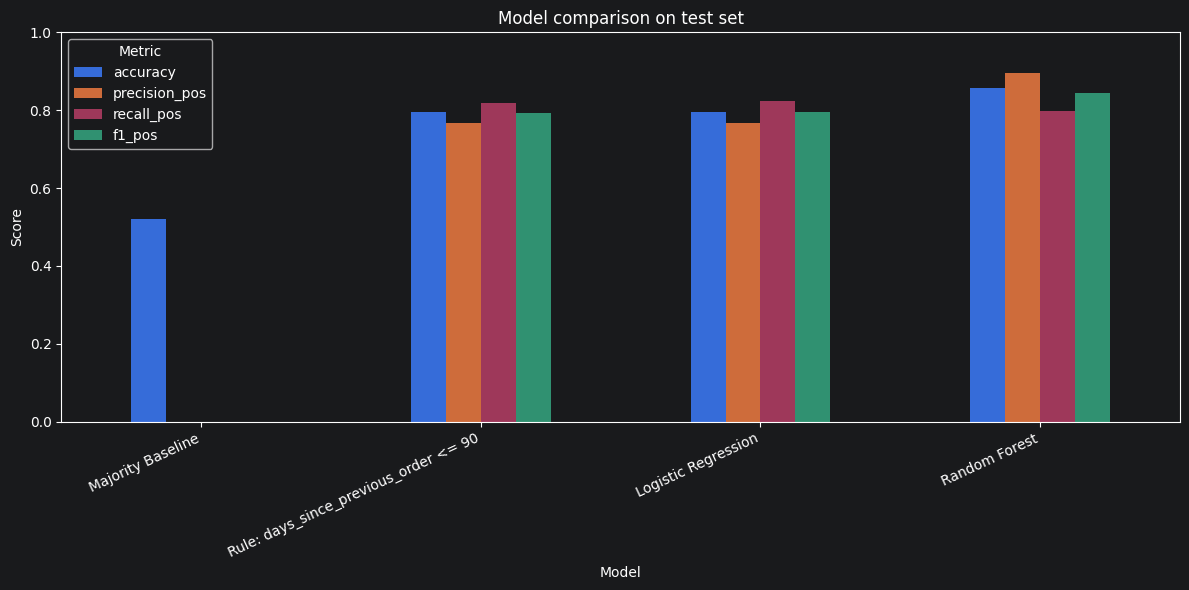

In [31]:
import matplotlib.pyplot as plt
import os

OUTPUT_DIR = "../outputs/bai3_repurchase_90d"
os.makedirs(OUTPUT_DIR, exist_ok=True)

test_compare_pd = final_results_pd[final_results_pd["split"] == "Test"].copy()

metrics_to_plot = ["accuracy", "precision_pos", "recall_pos", "f1_pos"]

plot_df = test_compare_pd[["model"] + metrics_to_plot].set_index("model")

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model comparison on test set")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/model_comparison_test.png", dpi=300)
plt.show()

Confusion matrix của Random Forest

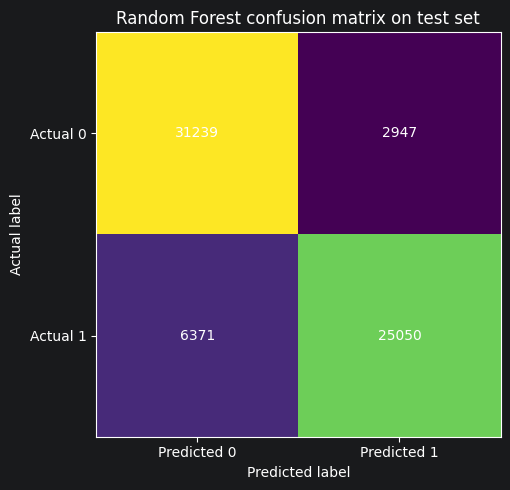

In [32]:
rf_test_cm = rf_test_result

cm_values = [
    [rf_test_cm["TN"], rf_test_cm["FP"]],
    [rf_test_cm["FN"], rf_test_cm["TP"]]
]

plt.figure(figsize=(6, 5))
plt.imshow(cm_values)
plt.title("Random Forest confusion matrix on test set")
plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_values[i][j]), ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/rf_confusion_matrix_test.png", dpi=300)
plt.show()

Biểu đồ threshold trên validation

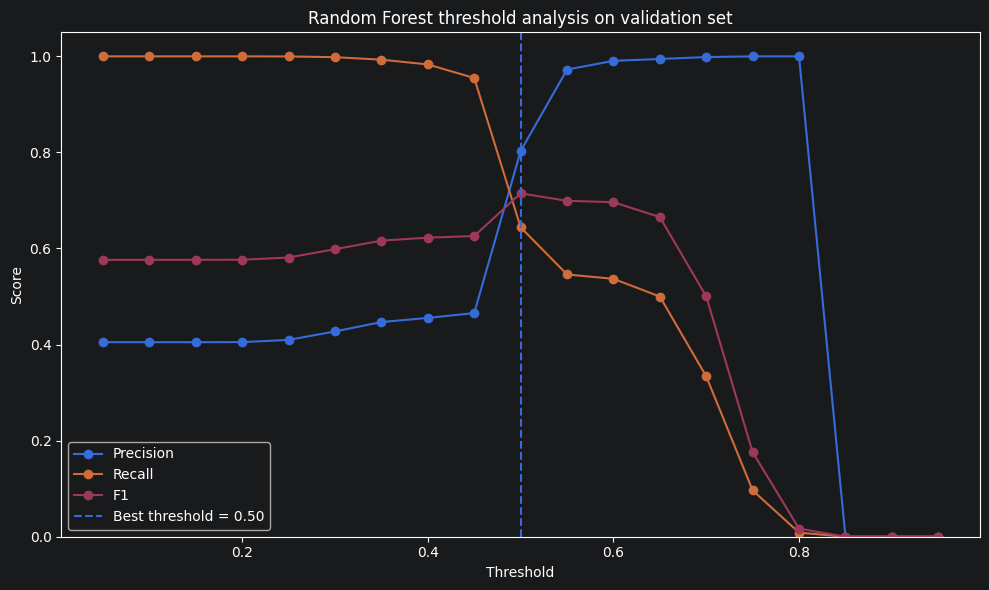

In [33]:
rf_valid_threshold_pd = rf_valid_threshold_metrics.toPandas()

plt.figure(figsize=(10, 6))

plt.plot(rf_valid_threshold_pd["threshold"], rf_valid_threshold_pd["precision_pos"], marker="o", label="Precision")
plt.plot(rf_valid_threshold_pd["threshold"], rf_valid_threshold_pd["recall_pos"], marker="o", label="Recall")
plt.plot(rf_valid_threshold_pd["threshold"], rf_valid_threshold_pd["f1_pos"], marker="o", label="F1")

plt.axvline(BEST_RF_THRESHOLD, linestyle="--", label=f"Best threshold = {BEST_RF_THRESHOLD:.2f}")

plt.title("Random Forest threshold analysis on validation set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/rf_threshold_analysis_validation.png", dpi=300)
plt.show()

Top feature importance

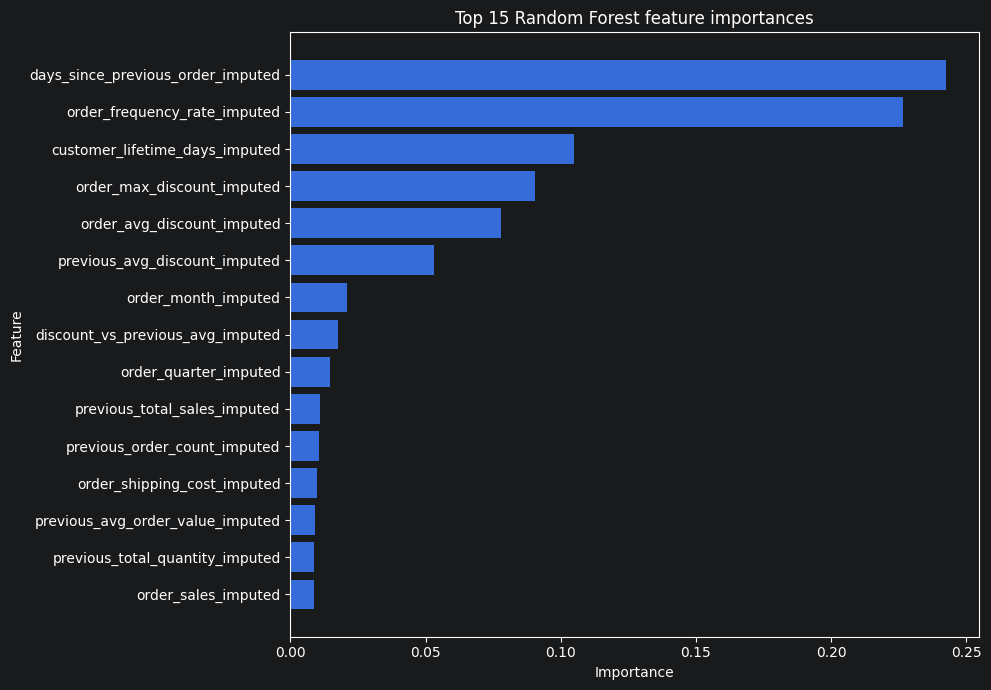

In [34]:
top15_importance_pd = importance_pd.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top15_importance_pd["feature"], top15_importance_pd["importance"])

plt.title("Top 15 Random Forest feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIR}/rf_top15_feature_importance.png", dpi=300)
plt.show()